In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-11-13 14:26:50.417154


# Nuclear and whole cell data branches

* https://www.10xgenomics.com/support/software/xenium-onboard-analysis/3.1/tutorials/outputs/xoa-output-understanding-outputs
* https://www.10xgenomics.com/support/software/xenium-onboard-analysis/3.1/advanced/example-code
  

Go to "Transcript data"

"The transcripts file (transcripts.parquet) is provided in Parquet format to enable faster loading and reading of data (code examples here). It contains data to evaluate transcript quality and localization. The file contains one row for each decoded transcript"


Basically we need to subset on nuclear transcripts which are stored in the parquet file. So after creating the anndata split it into nuclear and whole-cell branches.

In [2]:
from pathlib import Path
import dask.dataframe as dd
import os
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt

In [3]:
base_dir = Path("/home/workspace/projects/drg")

h5ad_dir     = base_dir / "data/h5ad/export_01/01_raw/output_folder"
whole_dir = h5ad_dir
xenium_root  = base_dir / "download/isolon"

out_main     = base_dir / "data/h5ad/export_test/nuclear_added"
out_nuclear  = base_dir / "data/h5ad/export_test/nuclear_only"
nuc_dir = out_nuclear


out_main.mkdir(parents=True, exist_ok=True)
out_nuclear.mkdir(parents=True, exist_ok=True)

In [4]:
#whole_dir = base_dir / "data/h5ad/export_01/01_raw/output_folder"


In [5]:
def load_nuclear_matrix(parquet_path, genes, cells):
    df = dd.read_parquet(parquet_path)
    nuc = df[df["overlaps_nucleus"] == 1].compute()
    mat = (
        nuc.groupby(["cell_id", "feature_name"])
        .size()
        .unstack(fill_value=0)
    )
    mat = mat.reindex(index=cells).fillna(0)
    mat = mat.reindex(columns=genes).fillna(0)
    return mat

for fname in os.listdir(h5ad_dir):

    if not fname.endswith(".h5ad"):
        continue

    print(f"\nProcessing {fname} ...")

    # Load whole-cell h5ad
    adata = ad.read_h5ad(f"{h5ad_dir}/{fname}")

    # Find matching transcripts.parquet
    run_id = adata.obs["xenium_run_id"].iloc[0]
    parquet_path = f"{xenium_root}/{run_id}/transcripts.parquet"

    genes = adata.var_names
    cells = adata.obs_names

    # Compute nuclear counts
    nuc_df = load_nuclear_matrix(parquet_path, genes, cells)
    nuclear = nuc_df.to_numpy()

    # Add nuclear layer to whole-cell data
    adata.layers["nuclear"] = nuclear

    # Compute nuclear fraction
    X = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X
    adata.obs["nuclear_fraction"] = nuclear.sum(1) / (X.sum(1) + 1e-9)

    # Save whole-cell + nuclear-layer version
    adata.write(f"{out_main}/{fname}")

    # ---- Create nuclear-only AnnData ----
    adata_nuc = ad.AnnData(
        X=nuclear,
        obs=adata.obs.copy(),
        var=adata.var.copy(),
        obsm=adata.obsm.copy(),
        uns=adata.uns.copy(),
    )
    adata_nuc.write(f"{out_nuclear}/{fname.replace('.h5ad','_nuclear.h5ad')}")

    print(f"Saved full-cell + nuclear layer: {out_main}/{fname}")
    print(f"Saved nuclear-only:              {out_nuclear}/{fname.replace('.h5ad','_nuclear.h5ad')}")


Processing TMA00304.h5ad ...
Saved full-cell + nuclear layer: /home/workspace/projects/drg/data/h5ad/export_test/nuclear_added/TMA00304.h5ad
Saved nuclear-only:              /home/workspace/projects/drg/data/h5ad/export_test/nuclear_only/TMA00304_nuclear.h5ad

Processing TMA00306.h5ad ...
Saved full-cell + nuclear layer: /home/workspace/projects/drg/data/h5ad/export_test/nuclear_added/TMA00306.h5ad
Saved nuclear-only:              /home/workspace/projects/drg/data/h5ad/export_test/nuclear_only/TMA00306_nuclear.h5ad

Processing TMA00303.h5ad ...
Saved full-cell + nuclear layer: /home/workspace/projects/drg/data/h5ad/export_test/nuclear_added/TMA00303.h5ad
Saved nuclear-only:              /home/workspace/projects/drg/data/h5ad/export_test/nuclear_only/TMA00303_nuclear.h5ad

Processing TMA00305.h5ad ...
Saved full-cell + nuclear layer: /home/workspace/projects/drg/data/h5ad/export_test/nuclear_added/TMA00305.h5ad
Saved nuclear-only:              /home/workspace/projects/drg/data/h5ad/exp

# correlation analysis & descriptive statistics

In [6]:
results = []

for fname in os.listdir(whole_dir):

    if not fname.endswith(".h5ad"):
        continue

    sample = fname.replace(".h5ad", "")
    whole_path = os.path.join(whole_dir, fname)
    nuc_path   = os.path.join(nuc_dir, f"{sample}_nuclear.h5ad")

    if not os.path.exists(nuc_path):
        continue

    whole = ad.read_h5ad(whole_path)
    nuc   = ad.read_h5ad(nuc_path)

    X = whole.X.toarray() if hasattr(whole.X, "toarray") else whole.X
    N = nuc.X.toarray()   if hasattr(nuc.X, "toarray") else nuc.X

    cell_corr = np.array([
        np.corrcoef(X[i], N[i])[0,1] if X[i].sum() > 0 else np.nan
        for i in range(X.shape[0])
    ])

    gene_corr = np.array([
        np.corrcoef(X[:,j], N[:,j])[0,1] if X[:,j].sum() > 0 else np.nan
        for j in range(X.shape[1])
    ])

    global_corr = np.corrcoef(X.flatten(), N.flatten())[0,1]

    results.append({
        "sample": sample,
        "cell_corr": cell_corr,
        "gene_corr": gene_corr,
        "global_corr": global_corr
    })

for r in results:
    print(r["sample"], "Global correlation:", r["global_corr"])

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: inv

TMA00304 Global correlation: 0.6818680796331559
TMA00306 Global correlation: 0.6538723684912456
TMA00303 Global correlation: 0.7127935648200788
TMA00305 Global correlation: 0.6775719901729447


Processing TMA00304 ...


/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


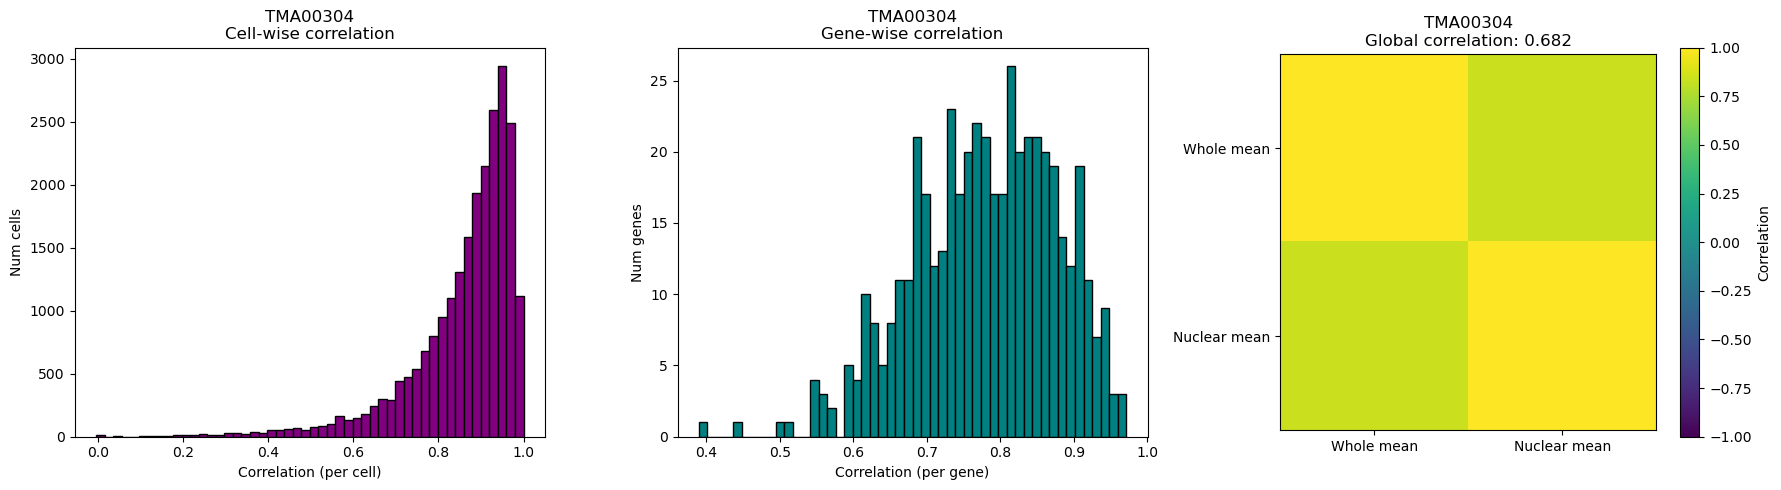

Processing TMA00306 ...


/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


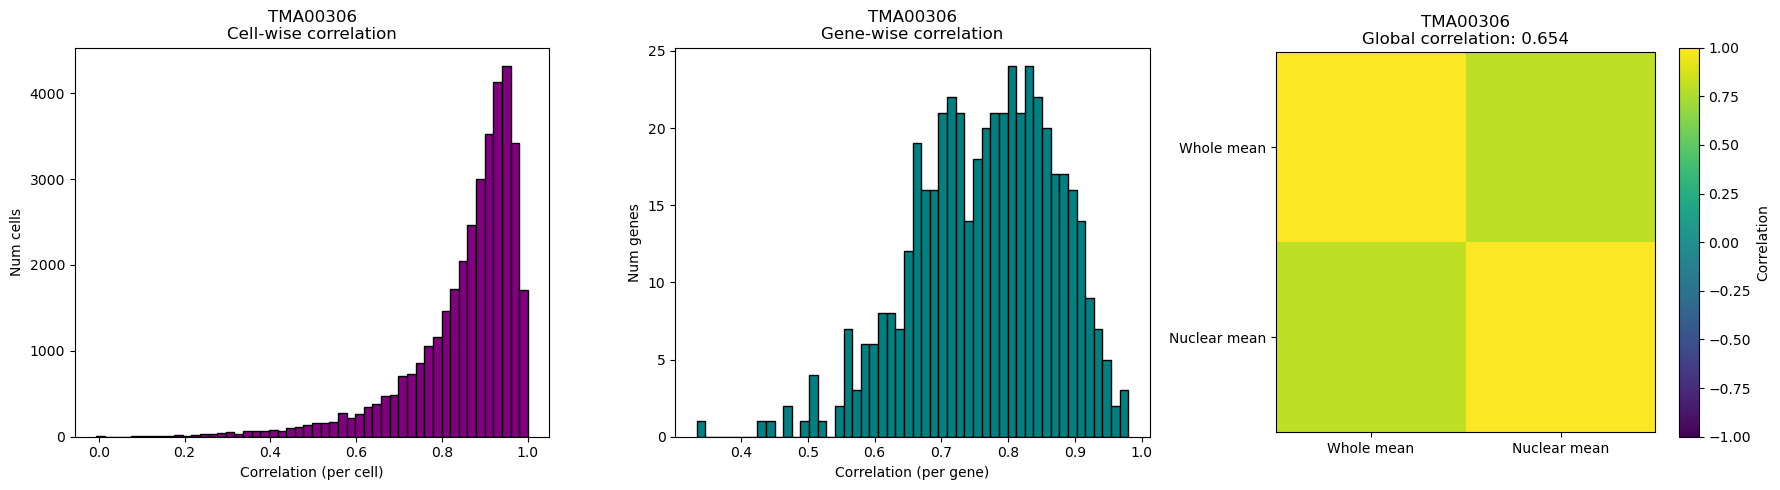

Processing TMA00303 ...


/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


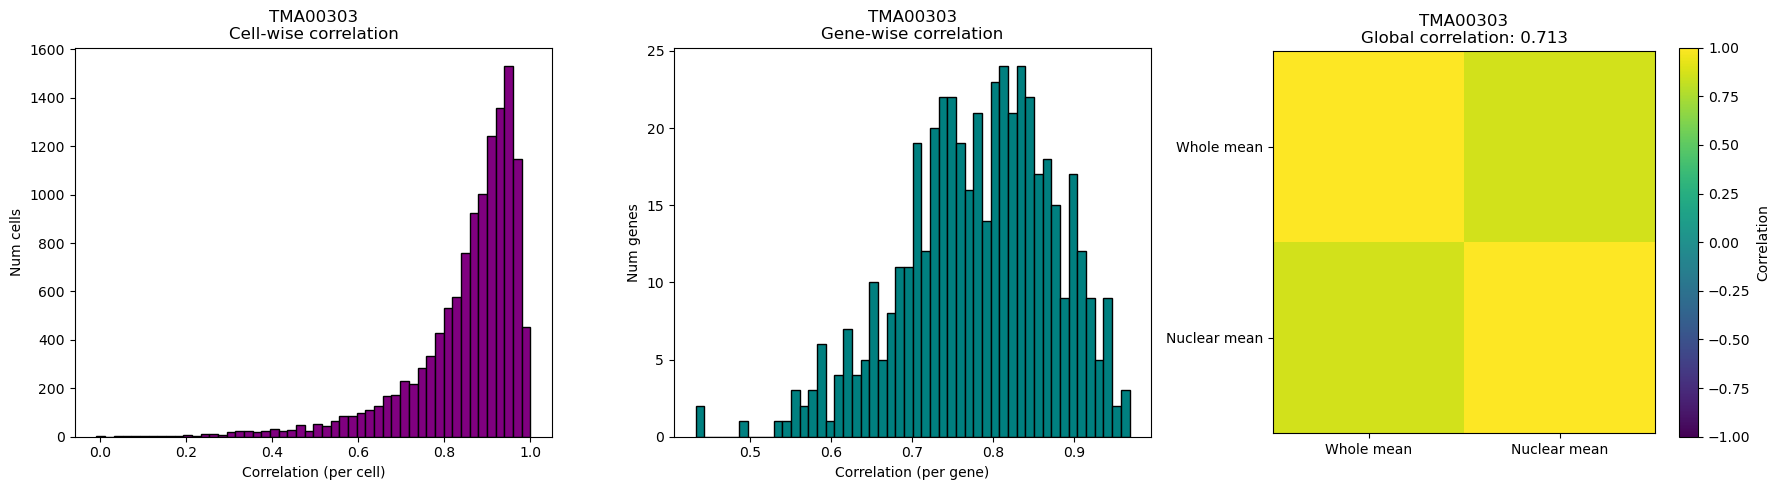

Processing TMA00305 ...


/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


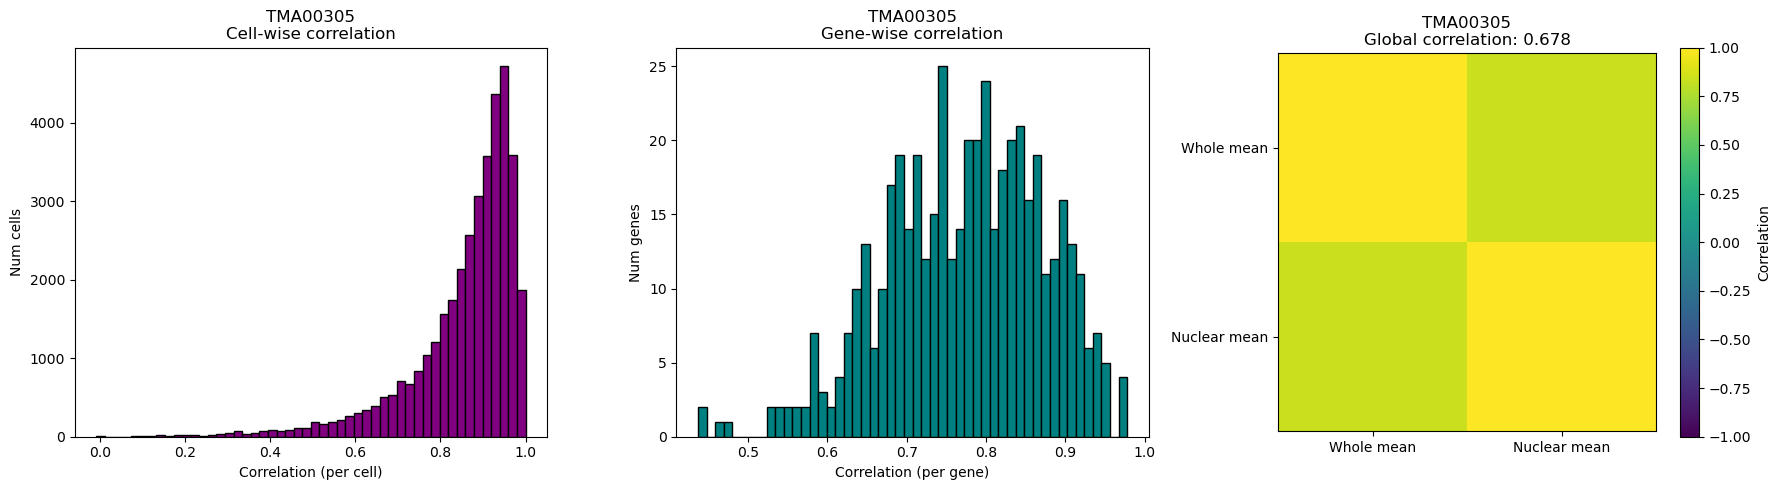

In [7]:
summary = []   # store global results here

for fname in os.listdir(whole_dir):

    if not fname.endswith(".h5ad"):
        continue

    sample = fname.replace(".h5ad","")
    nuc_file = f"{sample}_nuclear.h5ad"
    nuc_path = nuc_dir / nuc_file

    if not nuc_path.exists():
        print(f" Missing nuclear file for: {sample}")
        continue

    print(f"Processing {sample} ...")

    # --- load ---
    whole = ad.read_h5ad(whole_dir / fname)
    nuc   = ad.read_h5ad(nuc_path)

    # --- extract matrices ---
    X = whole.X.toarray() if hasattr(whole.X, "toarray") else whole.X
    N = nuc.X.toarray()   if hasattr(nuc.X, "toarray") else nuc.X

    # --- compute correlations ---
    cell_corr = np.array([
        np.corrcoef(X[i], N[i])[0,1] if X[i].sum() > 0 else np.nan
        for i in range(X.shape[0])
    ])

    gene_corr = np.array([
        np.corrcoef(X[:,j], N[:,j])[0,1] if X[:,j].sum() > 0 else np.nan
        for j in range(X.shape[1])
    ])

    global_corr = np.corrcoef(X.flatten(), N.flatten())[0,1]

    summary.append([sample, np.nanmean(cell_corr), np.nanmean(gene_corr), global_corr])

    # Data viz
    plt.figure(figsize=(18, 5))

    ## A. Cell-wise correlation
    plt.subplot(1, 3, 1)
    plt.hist(cell_corr[~np.isnan(cell_corr)], bins=50, color="purple", edgecolor="black")
    plt.xlabel("Correlation (per cell)")
    plt.ylabel("Num cells")
    plt.title(f"{sample}\nCell-wise correlation")

    ## B. Gene-wise correlation
    plt.subplot(1, 3, 2)
    plt.hist(gene_corr[~np.isnan(gene_corr)], bins=50, color="teal", edgecolor="black")
    plt.xlabel("Correlation (per gene)")
    plt.ylabel("Num genes")
    plt.title(f"{sample}\nGene-wise correlation")

    ## C. 2×2 heatmap of mean expression correlation
    plt.subplot(1, 3, 3)
    corr_mat = np.corrcoef(X.mean(axis=0), N.mean(axis=0))
    plt.imshow(corr_mat, cmap="viridis", vmin=-1, vmax=1)
    plt.colorbar(label="Correlation")
    plt.xticks([0,1], ["Whole mean", "Nuclear mean"])
    plt.yticks([0,1], ["Whole mean", "Nuclear mean"])
    plt.title(f"{sample}\nGlobal correlation: {global_corr:.3f}")

    ## Save plot
    #out_png = plot_dir / f"{sample}_correlation_QC.png"
    plt.tight_layout()
    #plt.savefig(out_png)
    plt.show()

    #print(f"  → saved {out_png}")

In [8]:
summary_df = pd.DataFrame(summary, columns=[
    "sample", "mean_cell_corr", "mean_gene_corr", "global_corr"
])

print("\n=== Correlation Summary Across Samples ===")
print(summary_df)


=== Correlation Summary Across Samples ===
     sample  mean_cell_corr  mean_gene_corr  global_corr
0  TMA00304        0.858065        0.779315     0.681868
1  TMA00306        0.852745        0.765401     0.653872
2  TMA00303        0.852036        0.781430     0.712794
3  TMA00305        0.854565        0.773685     0.677572


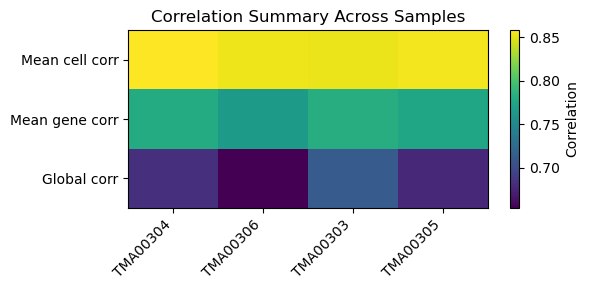

In [9]:
plt.figure(figsize=(6, 3))
plt.imshow(
    summary_df.set_index("sample").T,
    aspect="auto",
    cmap="viridis"
)
plt.colorbar(label="Correlation")

plt.xticks(
    ticks=range(len(summary_df)),
    labels=summary_df["sample"],
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=[0,1,2],
    labels=["Mean cell corr", "Mean gene corr", "Global corr"]
)

plt.title("Correlation Summary Across Samples")
plt.tight_layout()
plt.show()

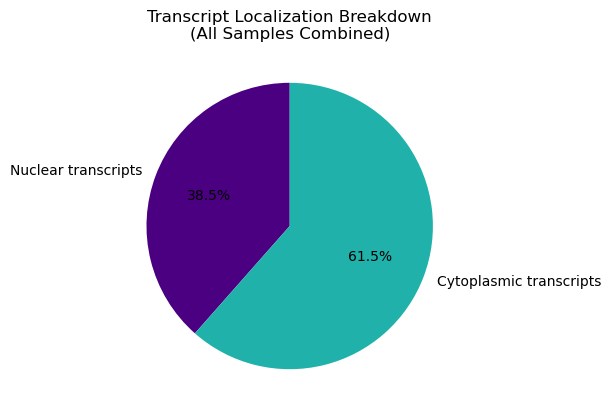

In [10]:
total_nuclear = 0
total_cyto = 0

for fname in os.listdir(whole_dir):

    if not fname.endswith(".h5ad"):
        continue

    sample = fname.replace(".h5ad","")
    nuc_path = os.path.join(nuc_dir, f"{sample}_nuclear.h5ad")

    if not os.path.exists(nuc_path):
        print(f"Missing nuclear file for: {sample}")
        continue

    # load
    whole = ad.read_h5ad(os.path.join(whole_dir, fname))
    nuc   = ad.read_h5ad(nuc_path)

    # extract matrices
    X = whole.X.toarray() if hasattr(whole.X, "toarray") else whole.X
    N = nuc.X.toarray()   if hasattr(nuc.X, "toarray") else nuc.X

    # sum for this sample
    nuclear_counts = N.sum()
    whole_counts   = X.sum()
    cyto_counts    = whole_counts - nuclear_counts

    total_nuclear += nuclear_counts
    total_cyto    += cyto_counts


# pie chart
labels = ["Nuclear transcripts", "Cytoplasmic transcripts"]
sizes  = [total_nuclear, total_cyto]

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4B0082", "#20B2AA"]  # purple nuclear, teal cyto
)
plt.title("Transcript Localization Breakdown\n(All Samples Combined)")
plt.tight_layout()
plt.show()

In [11]:
print("Total nuclear transcripts:     ", total_nuclear)
print("Total cytoplasmic transcripts: ", total_cyto)
print("Nuclear fraction:              ", total_nuclear / (total_nuclear + total_cyto))

Total nuclear transcripts:      17347787.0
Total cytoplasmic transcripts:  27728699.0
Nuclear fraction:               0.3848522486868209
